# 06 · Climate vs fuel: does minimising fuel minimise climate?

Airlines optimise **fuel burn**; the planet cares about **total climate forcing**. Aviation warms the climate through CO₂ *and* a set of non-CO₂ effects — NOx that makes and destroys ozone, water vapour, soot/sulphate aerosols, and persistent **contrails** — several of which depend on *where* you fly. So the minimum-fuel cruise altitude need not be the minimum-climate one.

Instead of inventing a climate proxy, we use **PhlyGreen's real `ClimateImpact` model**: it computes the gas-turbine emissions, the radiative forcing of every species, and the **Average Temperature Response (ATR)** — and we *test the hypothesis* directly.

## The real model (no proxy)

`ClimateImpact` (see `examples/14`) models:

- **Emissions**: CO₂, H₂O, SO₄, soot, and **NOx** from a gas-turbine correlation (Filippone) evaluated along the real power/altitude/speed trajectory.
- **Radiative forcing** of each species, including **altitude-dependent** NOx→ozone chemistry and persistent contrails (AIC, gated by temperature).
- **ATR(H)**: the average global-mean temperature response over a horizon `H`, the single climate metric we rank on.

We attach it to a kerosene turboprop and sweep the cruise altitude. The ATR involves nested time integrals, so the sweep is deliberately short.

In [1]:
import warnings
warnings.filterwarnings("ignore")     # keep the solver's internal chatter out of the output
import numpy as np
import matplotlib.pyplot as plt

from _learning_utils import add_examples_to_path
add_examples_to_path()                # puts trunk/examples on sys.path (no absolute paths)

import PhlyGreen as pg
import PhlyGreen.Utilities.Atmosphere as ISA
from common import traditional_config
from _learning_utils import set_cruise_altitude, attach_climate_model, climate_atr

# A kerosene turboprop carrying PhlyGreen's REAL climate model: gas-turbine emissions
# (CO2, H2O, SO4, soot, and NOx via the Filippone gas-turbine correlation), the radiative
# forcing of every species (incl. altitude-dependent NOx-ozone chemistry and persistent
# contrails / AIC), and the resulting Average Temperature Response (ATR). Same machinery as
# examples/14 — no proxy.
def kerosene_climate(alt_m):
    cfg = traditional_config()
    set_cruise_altitude(cfg, alt_m)
    attach_climate_model(cfg, einox_model="Filippone")
    return cfg

cfg0 = kerosene_climate(8000)
print("climate time horizon H =", cfg0.climate_impact.H, "yr")
print("NOx model              =", cfg0.climate_impact.einox_model, "(semi-empirical gas-turbine correlation)")


climate time horizon H = 100 yr
NOx model              = Filippone (semi-empirical gas-turbine correlation)


## Sweep cruise altitude: fuel *and* real ATR

For each cruise altitude we size the aircraft, read the block fuel, and evaluate the ATR **twice** — the full ATR (CO₂ + all non-CO₂ terms) and a **CO₂-only** ATR. The gap between them is precisely the warming that a CO₂-only (or fuel-only) metric ignores.

In [2]:
# Sweep cruise altitude. For each design we read the block fuel and compute the ATR twice:
# the full ATR (CO2 + every non-CO2 effect) and a CO2-only ATR, so we can see exactly how
# much warming a CO2-only accounting would miss. (ATR integrates the climate response over
# H years, so this cell takes ~30-60 s.)
alts = np.array([5000, 6000, 7000, 8000, 8500, 9000, 9500])   # cruise altitude [m]
fuel, atr_full, atr_co2, nox, T_cruise, T_weighted = ([] for _ in range(6))
for h in alts:
    a = pg.build_aircraft(); a.configure(kerosene_climate(h))
    fuel.append(a.results().block_fuel)
    atr_full.append(climate_atr(a, co2_only=False))     # CO2 + non-CO2 (NOx, contrails, H2O, ...)
    atr_co2.append(climate_atr(a, co2_only=True))        # CO2 only
    nox.append(a.climateimpact.mission_emissions["nox"])
    T_cruise.append(ISA.atmosphere.Tstd(float(h)))                              # static T at cruise
    T_weighted.append(ISA.atmosphere.Tstd(a.climateimpact.media_pesata_quote))  # mission-weighted T
fuel, atr_full, atr_co2, nox = map(np.array, (fuel, atr_full, atr_co2, nox))
T_cruise, T_weighted = np.array(T_cruise), np.array(T_weighted)
i_fuel = int(np.argmin(fuel)); i_clim = int(np.argmin(atr_full))
print(f"min-FUEL    cruise altitude : {alts[i_fuel]} m   ({fuel[i_fuel]:,.0f} kg block fuel)")
print(f"min-CLIMATE cruise altitude : {alts[i_clim]} m   (ATR {atr_full[i_clim]*1e3:.3f} mK)")


min-FUEL    cruise altitude : 6000 m   (1,982 kg block fuel)
min-CLIMATE cruise altitude : 6000 m   (ATR 2.882 mK)


## Fuel and climate vs altitude

Left: block fuel. Right: the full ATR and the CO₂-only ATR. Watch where each is minimised.

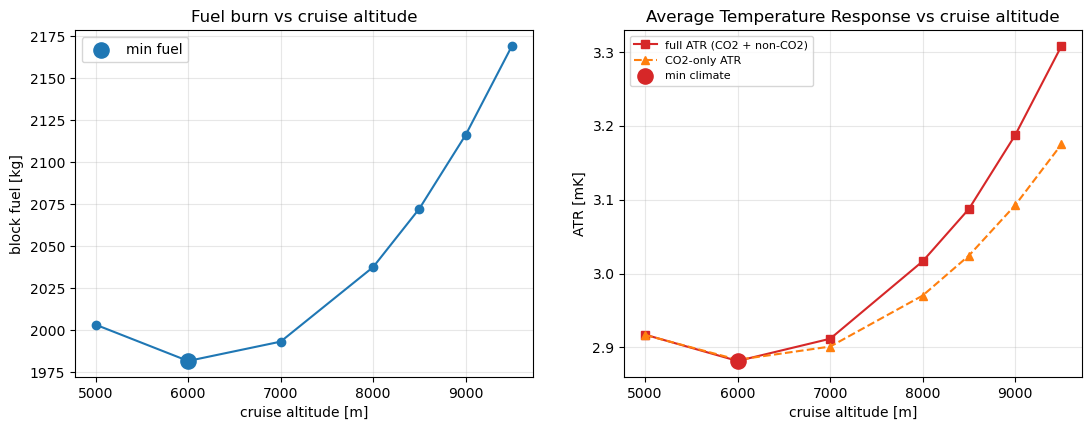

In [3]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))
axL.plot(alts, fuel, "o-", color="tab:blue")
axL.scatter([alts[i_fuel]], [fuel[i_fuel]], s=120, color="tab:blue", zorder=5, label="min fuel")
axL.set_xlabel("cruise altitude [m]"); axL.set_ylabel("block fuel [kg]")
axL.set_title("Fuel burn vs cruise altitude"); axL.grid(alpha=0.3); axL.legend()

axR.plot(alts, atr_full * 1e3, "s-", color="tab:red", label="full ATR (CO2 + non-CO2)")
axR.plot(alts, atr_co2 * 1e3, "^--", color="tab:orange", label="CO2-only ATR")
axR.scatter([alts[i_clim]], [atr_full[i_clim] * 1e3], s=120, color="tab:red", zorder=5, label="min climate")
axR.set_xlabel("cruise altitude [m]"); axR.set_ylabel("ATR [mK]")
axR.set_title("Average Temperature Response vs cruise altitude")
axR.grid(alpha=0.3); axR.legend(fontsize=8)
plt.show()


For *this regional turboprop* both the fuel burn and the full ATR bottom out at **the same cruise altitude (~6000 m)** — here, reducing fuel really does reduce climate impact. That is **not** a universal law; it holds because (1) the long-lived CO₂ dominates the ATR and tracks fuel, and (2) the big non-CO₂ lever — contrails — never switches on (next panels).

## How much does CO₂-only accounting miss?

The non-CO₂ share is the gap between the full and CO₂-only ATR. It is small here but **grows with altitude**, driven by the gas-turbine NOx (more NOx, and more potent ozone forcing, higher up).

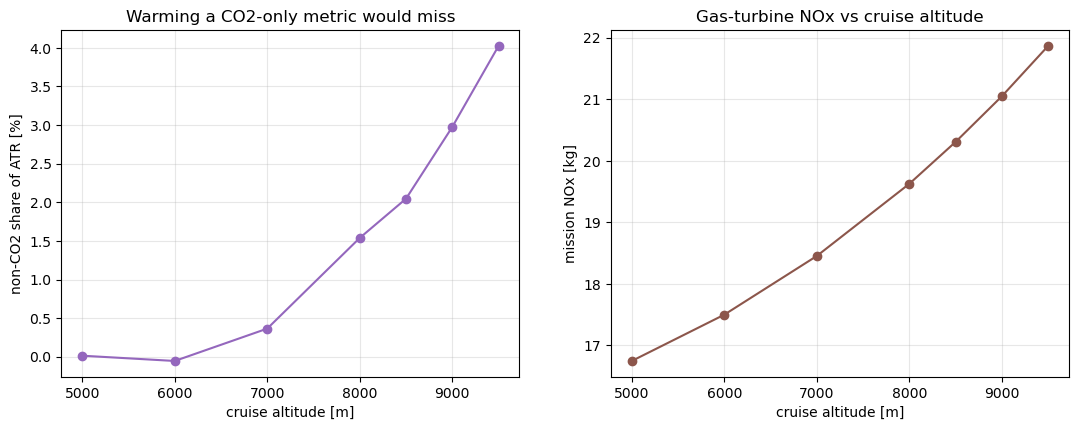

non-CO2 share of ATR grows from 0.0% at 5000 m to 4.0% at 9500 m.


In [4]:
nonco2_share = 100.0 * (atr_full - atr_co2) / atr_full
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))
axL.plot(alts, nonco2_share, "o-", color="tab:purple")
axL.set_xlabel("cruise altitude [m]"); axL.set_ylabel("non-CO2 share of ATR [%]")
axL.set_title("Warming a CO2-only metric would miss"); axL.grid(alpha=0.3)
axR.plot(alts, nox, "o-", color="tab:brown")
axR.set_xlabel("cruise altitude [m]"); axR.set_ylabel("mission NOx [kg]")
axR.set_title("Gas-turbine NOx vs cruise altitude"); axR.grid(alpha=0.3)
plt.show()
print(f"non-CO2 share of ATR grows from {nonco2_share[0]:.1f}% at {alts[0]} m "
      f"to {nonco2_share[-1]:.1f}% at {alts[-1]} m.")


So even where CO₂ dominates, a CO₂-only metric increasingly **under-counts** warming as you climb. The slice is a few percent for this turboprop — but it is the *visible tip* of the effect that dominates for high-altitude jets.

## Why is there no strong trade-off here? The contrail gate

Persistent contrails — often aviation's single largest non-CO₂ forcing — only form in cold, ice-supersaturated air (roughly below ~235 K). PhlyGreen gates contrail forcing on the **mission-weighted** temperature. The turboprop's cruise air *is* cold enough, but the mission-weighted altitude is dragged down by the long climb/descent and the low-altitude diversion — so it stays warm and **contrails never trigger**.

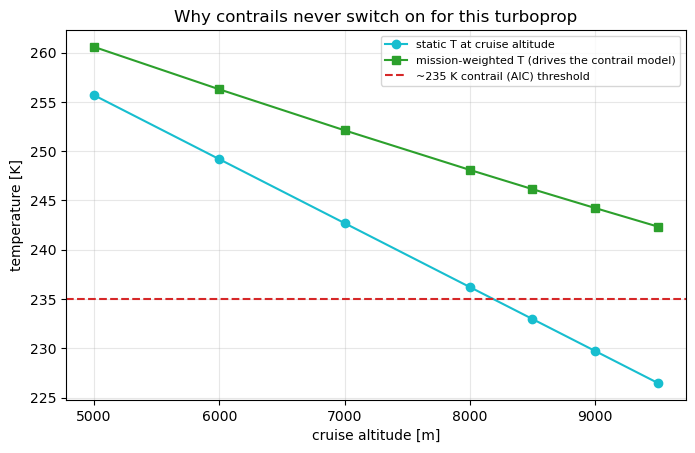

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(alts, T_cruise, "o-", color="tab:cyan", label="static T at cruise altitude")
ax.plot(alts, T_weighted, "s-", color="tab:green", label="mission-weighted T (drives the contrail model)")
ax.axhline(235, color="tab:red", ls="--", label="~235 K contrail (AIC) threshold")
ax.set_xlabel("cruise altitude [m]"); ax.set_ylabel("temperature [K]")
ax.set_title("Why contrails never switch on for this turboprop")
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.show()


The mission-weighted temperature (green) never drops below the red threshold, so the contrail term is zero across the whole sweep. A **high-altitude jet** cruising at 11–12 km lives the opposite life: its *fuel-optimal* cruise sits squarely in the contrail-forming band, so for a jet the minimum-fuel altitude is decidedly **not** the minimum-climate one. That is the regime where 'fly a bit lower' is a real climate lever.

## The fuel–climate plane

Plotting full ATR against fuel, coloured by altitude: for this aircraft the two are **positively correlated** and share a minimum, so the min-fuel and min-climate markers land on essentially the same point. For a jet (or once contrails switch on) this scatter would open into a genuine trade-off front with the two markers far apart.

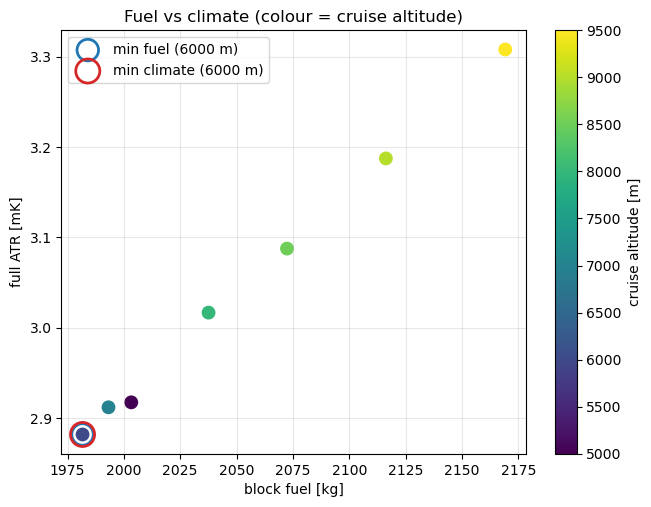

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
sc = ax.scatter(fuel, atr_full * 1e3, c=alts, cmap="viridis", s=80)
ax.scatter([fuel[i_fuel]], [atr_full[i_fuel] * 1e3], edgecolor="tab:blue", facecolor="none",
           s=240, linewidth=2, label=f"min fuel ({alts[i_fuel]} m)")
ax.scatter([fuel[i_clim]], [atr_full[i_clim] * 1e3], edgecolor="tab:red", facecolor="none",
           s=300, linewidth=2, label=f"min climate ({alts[i_clim]} m)")
cb = fig.colorbar(sc, ax=ax); cb.set_label("cruise altitude [m]")
ax.set_xlabel("block fuel [kg]"); ax.set_ylabel("full ATR [mK]")
ax.set_title("Fuel vs climate (colour = cruise altitude)")
ax.grid(alpha=0.3); ax.legend()
plt.show()


## Key takeaways

1. **CO₂/fuel is not the whole climate story.** The real model adds NOx-ozone, water vapour, aerosols and contrails — and we computed them, not a proxy.
2. **Whether min-fuel = min-climate depends on the aircraft.** For this low-flying turboprop they coincide (CO₂-dominated, no contrails); for a high-altitude jet they diverge (fuel-optimal cruise is contrail-forming).
3. **A CO₂-only objective is dangerous** precisely because it omits the altitude- and route-dependent non-CO₂ terms — small here (a few %), dominant for jets.

## Questions for students

1. Why can reducing fuel burn fail to minimise total climate impact? Under what conditions does it *succeed* (as it does here)?
2. What is the danger of using CO₂ (or fuel) as the sole climate objective?
3. The contrail term here depends on a *mission-weighted* temperature. Is that a good modelling choice? What would change if contrails were gated on the *cruise* temperature instead?

## Suggested modifications

- **Stretch the cruise.** Increase `range_mission` so cruise dominates the mission-weighted altitude — does the contrail term ever switch on?
- **Change the horizon.** Lower the climate horizon `H` (short-lived contrails/NOx weigh more at short horizons) and see whether the non-CO₂ share grows.
- **Vary the emission intensities.** Change `wtw_co2` in `attach_climate_model` (e.g. a SAF or e-fuel lifecycle value) and watch the CO₂-driven part of the ATR move.
- **Imagine a jet.** Sketch what the fuel-vs-altitude curve would look like for a jet (fuel-optimal at 11–12 km) and argue where its min-climate altitude would sit.

---
*These tutorials are educational. Notebook 06 uses PhlyGreen's real ClimateImpact model (gas-turbine emissions + radiative forcing → ATR); the only simplification is the Filippone NOx correlation and the usual modelling assumptions inside that module — read its docstring before quoting a figure.*